# Phase 4 — Region-partitioning MKNN read-out

This is the phase's real read-out notebook, not a `CLAUDE.md` sanity check — it legitimately
reads `notebooks/.cache/04_region_partition_mknn.jsonl`, the JSONL cache written by
`notebooks/diagnostics/region_partition_mknn_run.py`. All compute lives in that runner; this
notebook computes nothing heavy, following this repo's runner + JSONL cache + notebook pattern.

Sections: **0** provenance, **1** MKNN-01 (the metric, its known-answer checks, and why the
standing Swiss roll rule is not triggered here), **2** MKNN-02 (the global crossmodal
reproduction against the origin paper).

## Section 0 — Provenance

In [1]:
import subprocess
import sys
from pathlib import Path

# import pu_manifold and the diagnostics runner exactly as the other notebooks do -- relative,
# never from src/effdim/. "diagnostics" is an implicit namespace package (no __init__.py).
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import scipy
import sklearn

from pu_manifold import curvature_probe, mknn
from diagnostics import region_partition_mknn_run as rpm

git_sha = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True).strip()

X_hsc, X_ls, subsample_file = rpm.load_pu_pair()

print(f"resolved subsample file : {Path(subsample_file).name}")
print(f"row count                : {X_hsc.shape[0]}")
print(f"columns                  : hsc {X_hsc.shape}, legacysurvey {X_ls.shape}")
print(f"numpy                    : {np.__version__}")
print(f"scipy                    : {scipy.__version__}")
print(f"scikit-learn             : {sklearn.__version__}")
print(f"git HEAD                 : {git_sha}")
print(f"curvature_probe.CURVATURE_CONVENTION : {curvature_probe.CURVATURE_CONVENTION!r}")

loaded hsc (10000, 768) and legacysurvey (10000, 768) from subsample_20260729_a79b3460b838fd0a.npz
resolved subsample file : subsample_20260729_a79b3460b838fd0a.npz
row count                : 10000
columns                  : hsc (10000, 768), legacysurvey (10000, 768)
numpy                    : 2.5.1
scipy                    : 1.18.0
scikit-learn             : 1.9.0
git HEAD                 : 647d01d
curvature_probe.CURVATURE_CONVENTION : 'trace'


## Section 1 — MKNN-01: the metric and its sanity checks

**Formula** (Chechik et al. 2010, adopted verbatim by arXiv:2509.19453, cited here as the
direct, verified source):

$$\mathrm{MKNN}(z_1, z_2) = k^{-1} \, \bigl| N_k(z_1) \cap N_k(z_2) \bigr|$$

with $N_k(z)$ the k-NN index set within $z$'s own embedding space, self excluded. The paper
attributes the metric to Chechik et al. 2010; that attribution is repeated as the paper's own
citation choice here and was not independently re-verified (RESEARCH A2, disposed — see
`04-01-PLAN.md` `flagged_assumptions`).

In [2]:
rng = np.random.default_rng(20260822)


def check(name: str, cond: bool) -> None:
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")
    assert cond, name


X = rng.normal(size=(400, 16))
Y = X.copy()
check("identical row-aligned pair scores exactly 1.0 at k=10", mknn.mknn_score(X, Y, 10) == 1.0)

Z = rng.normal(size=(20, 8))
check("k = n - 1 scores exactly 1.0", mknn.mknn_score(Z, Z.copy(), 19) == 1.0)

A = rng.normal(size=(400, 16))
B = rng.normal(size=(400, 16))
ind_score = mknn.mknn_score(A, B, 10)
floor = mknn.chance_floor(400, 10)
check(
    "independent Gaussian clouds (400, 16) land within a factor of 3 of chance_floor(400, 10)",
    floor / 3.0 <= ind_score <= floor * 3.0,
)

perm = rng.permutation(400)
base = mknn.mknn_score(X, Y, 10)
check(
    "simultaneous row permutation of both sides leaves the score unchanged",
    mknn.mknn_score(X[perm], Y[perm], 10) == base,
)
check("permuting one side only changes the score", mknn.mknn_score(X, Y[perm], 10) != base)

print("\nAll MKNN-01 known-answer assertions pass (identical to --selfcheck's, run inline here).")

  [PASS] identical row-aligned pair scores exactly 1.0 at k=10
  [PASS] k = n - 1 scores exactly 1.0
  [PASS] independent Gaussian clouds (400, 16) land within a factor of 3 of chance_floor(400, 10)
  [PASS] simultaneous row permutation of both sides leaves the score unchanged
  [PASS] permuting one side only changes the score

All MKNN-01 known-answer assertions pass (identical to --selfcheck's, run inline here).


**Why `CLAUDE.md`'s standing Swiss roll rule is not triggered here (D4-12).** That rule
targets models that map data to a lower-dimensional representation and back, or that claim to
recover manifold structure — chart auto-encoders, topological auto-encoders, decoder
parameterizations, curvature estimators. MKNN learns nothing: it has no latent space, no
training, and no reconstruction. It is a metric computed directly on two given embeddings, and
this phase's sign-split partition (plan `04-03`) reads an already-computed vector field rather
than recovering manifold structure itself. The estimator underneath that field is already
covered by `notebooks/02.5_swiss_roll_curvature_probe_check.ipynb`. The rule is not being
waived here — it does not apply to either MKNN or the sign-split partition.

## Section 2 — MKNN-02: the global crossmodal reproduction

In [3]:
import json

CACHE = Path("notebooks/.cache") if Path("notebooks/.cache").exists() else Path(".cache")
RECORD_PATH = CACHE / "04_region_partition_mknn.jsonl"

rows = []
with RECORD_PATH.open() as fh:
    for line in fh:
        r = json.loads(line)
        if r.get("region") == "global":
            rows.append(r)

# one row per k -- the most recent row for each k_mknn (later runs at the same seed reproduce
# bit-identically, so "most recent" and "first" agree on every value that matters)
by_k = {}
for r in rows:
    by_k[r["k_mknn"]] = r
global_rows = [by_k[k] for k in sorted(by_k)]

print(f"{len(rows)} global rows on disk, {len(global_rows)} distinct k_mknn: {sorted(by_k)}")
rpm.summarize(global_rows)

6 global rows on disk, 4 distinct k_mknn: [5, 10, 20, 50]

Global crossmodal MKNN read-out, full grid:
 k_mknn       n    score%    floor%    ratio        p   ci_low%  ci_high%   hub_hsc    hub_ls
      5   10000     4.882      0.05   97.640   0.0010     4.688     5.086     1.239     1.494
     10   10000     6.594       0.1   65.940   0.0010     6.417     6.781     1.118     1.319
     20   10000      8.98       0.2   44.902   0.0010     8.802     9.165     1.049     1.188
     50   10000     13.23       0.5   26.458   0.0010     13.03     13.43     0.966     1.013

--- comparison against the origin paper (D4-19) ---
this run:  n = 10000, raw MKNN 4sf shown above per k, ratio-over-chance carries
           the comparison across the n mismatch, NOT the raw number
paper:     Legacy-vs-HSC published range 0.34% - 2.25% at n = 101725 (arXiv:2509.19453 Table 2)
NOTE: n = 10000 here vs n = 101725 in the paper -- raw numbers are NOT directly comparable across this n mismatch; the ratio-over-

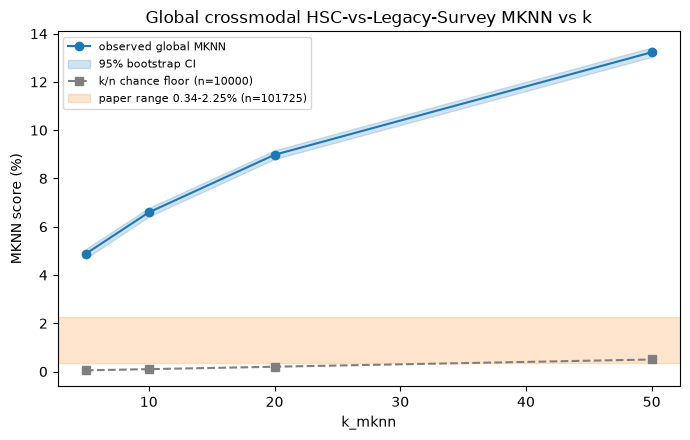

In [4]:
import matplotlib.pyplot as plt

ks = [r["k_mknn"] for r in global_rows]
scores_pct = [r["score"] * 100 for r in global_rows]
floors_pct = [r["chance_floor"] * 100 for r in global_rows]
ci_low_pct = [r["ci_low"] * 100 for r in global_rows]
ci_high_pct = [r["ci_high"] * 100 for r in global_rows]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, scores_pct, "o-", color="tab:blue", label="observed global MKNN")
ax.fill_between(
    ks,
    ci_low_pct,
    ci_high_pct,
    color="tab:blue",
    alpha=0.2,
    label="95% bootstrap CI",
)
ax.plot(ks, floors_pct, "s--", color="tab:gray", label="k/n chance floor (n=10000)")
ax.axhspan(
    rpm.PAPER_RANGE_LOW,
    rpm.PAPER_RANGE_HIGH,
    color="tab:orange",
    alpha=0.2,
    label=f"paper range {rpm.PAPER_RANGE_LOW}-{rpm.PAPER_RANGE_HIGH}% (n={rpm.PAPER_N})",
)
ax.set_xlabel("k_mknn")
ax.set_ylabel("MKNN score (%)")
ax.set_title("Global crossmodal HSC-vs-Legacy-Survey MKNN vs k")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
print("=== read-out ===")
for r in global_rows:
    inside = rpm.PAPER_RANGE_LOW <= r["score"] * 100 <= rpm.PAPER_RANGE_HIGH
    print(
        f"k={r['k_mknn']:>2}: score {r['score'] * 100:.4g}% is "
        f"{r['ratio_over_chance']:.2f}x its chance floor "
        f"({r['chance_floor'] * 100:.4g}%); "
        f"raw value falls {'INSIDE' if inside else 'OUTSIDE'} the paper's "
        f"{rpm.PAPER_RANGE_LOW}-{rpm.PAPER_RANGE_HIGH}% band (not directly comparable -- "
        f"n={r['n']} here vs n={rpm.PAPER_N} in the paper)"
    )

print(
    f"\nn mismatch stated plainly: this run is n={global_rows[0]['n']}, the paper's "
    f"Table 2 column is n={rpm.PAPER_N} -- an {rpm.PAPER_N / global_rows[0]['n']:.1f}x "
    "difference in sample size. Per D4-19, the ratio-over-chance is what carries the "
    "comparison across that mismatch, not the raw percentage falling inside or outside the "
    "band."
)

print("\n=== MKNN-08 hubness caveat, substantiated ===")
for r in global_rows:
    print(
        f"k={r['k_mknn']:>2}: k-occurrence skewness hsc={r['hubness_skewness_hsc']:.3f}, "
        f"legacysurvey={r['hubness_skewness_legacysurvey']:.3f}"
    )
hub_all = [r["hubness_skewness_hsc"] for r in global_rows] + [
    r["hubness_skewness_legacysurvey"] for r in global_rows
]
print(
    f"\nEvery MKNN result above carries the hubness caveat: k-NN alignment metrics are "
    "hubness-sensitive in high dimensions (Radovanovic, Nanopoulos and Ivanovic, JMLR 2010), "
    f"and the printed k-occurrence skewness (ranges {min(hub_all):.3f} to {max(hub_all):.3f} "
    "here, both embedding sides, every k) is the substantiating evidence for that caveat "
    "rather than a prose-only assertion of it."
)

=== read-out ===
k= 5: score 4.882% is 97.64x its chance floor (0.05%); raw value falls OUTSIDE the paper's 0.34-2.25% band (not directly comparable -- n=10000 here vs n=101725 in the paper)
k=10: score 6.594% is 65.94x its chance floor (0.1%); raw value falls OUTSIDE the paper's 0.34-2.25% band (not directly comparable -- n=10000 here vs n=101725 in the paper)
k=20: score 8.98% is 44.90x its chance floor (0.2%); raw value falls OUTSIDE the paper's 0.34-2.25% band (not directly comparable -- n=10000 here vs n=101725 in the paper)
k=50: score 13.23% is 26.46x its chance floor (0.5%); raw value falls OUTSIDE the paper's 0.34-2.25% band (not directly comparable -- n=10000 here vs n=101725 in the paper)

n mismatch stated plainly: this run is n=10000, the paper's Table 2 column is n=101725 -- an 10.2x difference in sample size. Per D4-19, the ratio-over-chance is what carries the comparison across that mismatch, not the raw percentage falling inside or outside the band.

=== MKNN-08 hubnes

## Section 3 -- the curvature field and the `k` freeze

In [6]:
from pu_manifold import region_partition

with (CACHE / "04_pu_curvature_rankability_corrected.jsonl").open() as fh:
    corrected_rows = [json.loads(line) for line in fh]

# most-recent row per k -- same last-write-wins convention cell 8 uses for global rows
by_k_corrected = {}
for r in corrected_rows:
    by_k_corrected[r["k"]] = r
corrected_rows_sorted = [by_k_corrected[k] for k in sorted(by_k_corrected)]

print(
    f"{len(corrected_rows)} corrected rows on disk, {len(corrected_rows_sorted)} distinct k: "
    f"{sorted(by_k_corrected)}"
)
print()
print(
    f"{'k':>5} {'median_R_H':>11} {'frac_neg':>9} {'median_r_dir':>13} {'h_p05':>10} "
    f"{'h_p50':>10} {'h_p95':>10} {'h_spread':>9} {'r_knn':>7} {'R_cloud':>8} {'r_over_R':>9}"
)
for r in corrected_rows_sorted:
    rel = r["reliability"]
    print(
        f"{r['k']:>5} {rel['median_R_H']:>11.4f} {rel['fraction_negative']:>9.3f} "
        f"{r['median_r_dir']:>+13.3f} {r['h_p05']:>10.4g} {r['h_p50']:>10.4g} "
        f"{r['h_p95']:>10.4g} {r['h_spread']:>9.2f} {r['r_knn']:>7.3f} {r['R_cloud']:>8.3f} "
        f"{r['r_over_R']:>9.4f}"
    )


6 corrected rows on disk, 6 distinct k: [30, 60, 120, 231, 350, 500]

    k  median_R_H  frac_neg  median_r_dir      h_p05      h_p50      h_p95  h_spread   r_knn  R_cloud  r_over_R
   30      0.0279     0.364        +0.034      2.842      6.471      13.77      4.85   0.264    0.377    0.6991
   60      0.0927     0.164        +0.105      5.506      10.74      22.21      4.03   0.279    0.377    0.7399
  120      0.1573     0.062        +0.175      6.741       12.5      27.22      4.04   0.297    0.377    0.7878
  231      0.2337     0.023        +0.260      7.311      13.12      29.45      4.03   0.317    0.377    0.8391
  350      0.2853     0.009        +0.314        7.5      13.31      30.01      4.00   0.331    0.377    0.8783
  500      0.3436     0.004        +0.374      7.585      13.33      29.91      3.94   0.345    0.377    0.9151


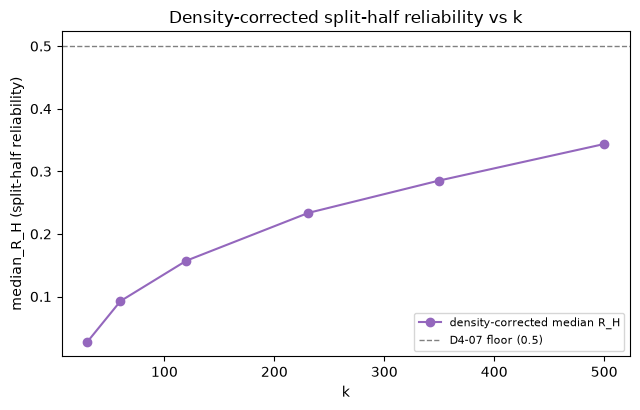

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ks_c = [r["k"] for r in corrected_rows_sorted]
medR_c = [r["reliability"]["median_R_H"] for r in corrected_rows_sorted]
ax.plot(ks_c, medR_c, "o-", color="tab:purple", label="density-corrected median R_H")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="D4-07 floor (0.5)")
ax.set_xlabel("k")
ax.set_ylabel("median_R_H (split-half reliability)")
ax.set_title("Density-corrected split-half reliability vs k")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [8]:
with (CACHE / "04_k_freeze.json").open() as fh:
    k_freeze = json.load(fh)

print(f"K_FROZEN   = {k_freeze['k_frozen']}")
print(f"rule_fired = {k_freeze['rule_fired']}")
print(f"rule_text  = {k_freeze['rule_text']}")
print()
print("per-k median_R_H and delta vs the immediately preceding sweep point:")
for k in k_freeze["k_grid"]:
    medR = k_freeze["median_R_H_by_k"][str(k)]
    delta = k_freeze["delta_by_k"][str(k)]
    delta_s = f"{delta:+.4f}" if delta is not None else "-- (undefined at the first point)"
    print(f"  k={k:>4}  median_R_H={medR:.4f}  delta={delta_s}")

assert region_partition.K_FROZEN == k_freeze["k_frozen"]

print()
print(
    "STATEMENT 1: the direction axis (median_r_dir) is reported in the SAME table above as "
    "every reliability figure -- it never appears separated from the numbers that qualify it."
)
print(
    "STATEMENT 2: r/R is reported for every k above. Spike 003 measured r/R crossing 1.0 at "
    "k=231 on its own fixtures -- above 1.0 the neighbourhood has grown past the cloud radius "
    "and is no longer local. Reported here for context; gated on by nothing (Spearman rank "
    "correlation is scale-free with respect to locality regime)."
)
if not k_freeze["rule_fired"]:
    print(
        f"\nrule_fired = False: the plateau was NOT demonstrated within the sweep budget. "
        f"K_FROZEN = {k_freeze['k_frozen']} is the largest k actually run -- a compute-budget "
        "ceiling, never described as converged, plateaued, or settled anywhere in this record."
    )


K_FROZEN   = 500
rule_fired = False
rule_text  = D4-07: freeze the curvature-field k at the smallest k in the ordered sweep grid whose median_R_H gain over the immediately preceding sweep point is strictly less than 0.03 AND whose median_R_H is greater than or equal to 0.5. The rule is evaluated from the SECOND sweep point onward, because the gain at the first point is undefined. If no k in the grid satisfies both conditions, the frozen k is the largest k actually run and the outcome is recorded as not-fired -- never adjusted post hoc.

per-k median_R_H and delta vs the immediately preceding sweep point:
  k=  30  median_R_H=0.0279  delta=-- (undefined at the first point)
  k=  60  median_R_H=0.0927  delta=+0.0648
  k= 120  median_R_H=0.1573  delta=+0.0646
  k= 231  median_R_H=0.2337  delta=+0.0763
  k= 350  median_R_H=0.2853  delta=+0.0516
  k= 500  median_R_H=0.3436  delta=+0.0583

STATEMENT 1: the direction axis (median_r_dir) is reported in the SAME table above as every reliability

## Section 4 -- REGN-01 and REGN-02, before the split is trusted

Ambient 768-d local density, reported and correlated against curvature **before** the frozen split (Section 5) is read as trustworthy -- the Manual-Only Verification table (04-VALIDATION.md) requires this cell to precede the partition cell in notebook order.

recomputed rho (ambient 768-d local density) for all 10000 points in 1.7s
rho p05=60706.8  p50=2.28661e+09  p95=3.63178e+12  spread(p95/p05)=5.98249e+07
local_density_weights' w is mean-normalized to 1, so rho = 1/w is a RELATIVE density, not an absolute one.


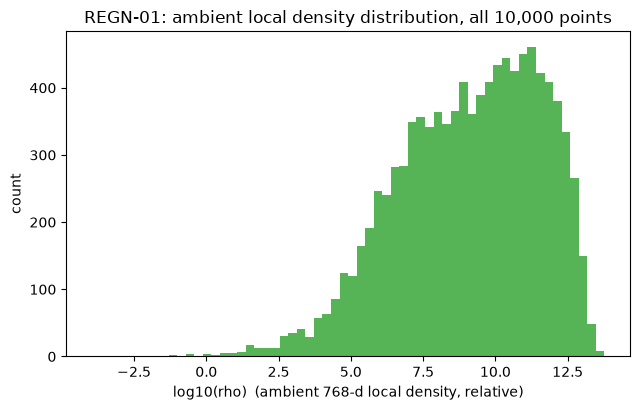

In [9]:
import time

with (CACHE / "04_density_diagnostics.json").open() as fh:
    density_diag = json.load(fh)

# Recomputed here rather than read from a per-point cache (rho itself is not persisted,
# only its summary percentiles) -- local_density_weights is a single k-NN query over the
# already-loaded (10000, 768) array, seconds not hours, unlike the field estimator itself.
t0 = time.monotonic()
w = curvature_probe.local_density_weights(
    X_ls, k_density=density_diag["k_density"], d=density_diag["d"]
)
rho = 1.0 / w
print(f"recomputed rho (ambient 768-d local density) for all {rho.shape[0]} points in {time.monotonic() - t0:.1f}s")
print(
    f"rho p05={density_diag['rho_p05']:.6g}  p50={density_diag['rho_p50']:.6g}  "
    f"p95={density_diag['rho_p95']:.6g}  spread(p95/p05)={density_diag['rho_p95_over_p05']:.6g}"
)
print(
    "local_density_weights' w is mean-normalized to 1, so rho = 1/w is a RELATIVE density, "
    "not an absolute one."
)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.hist(np.log10(rho), bins=60, color="tab:green", alpha=0.8)
ax.set_xlabel("log10(rho)  (ambient 768-d local density, relative)")
ax.set_ylabel("count")
ax.set_title("REGN-01: ambient local density distribution, all 10,000 points")
plt.tight_layout()
plt.show()


REGN-02 density vs ||H||: rho=-0.0273  p=0.007837  n=9500
REGN-02 density vs signed projection <H/||H||, v>: rho=+0.8208  p=0  n=9500


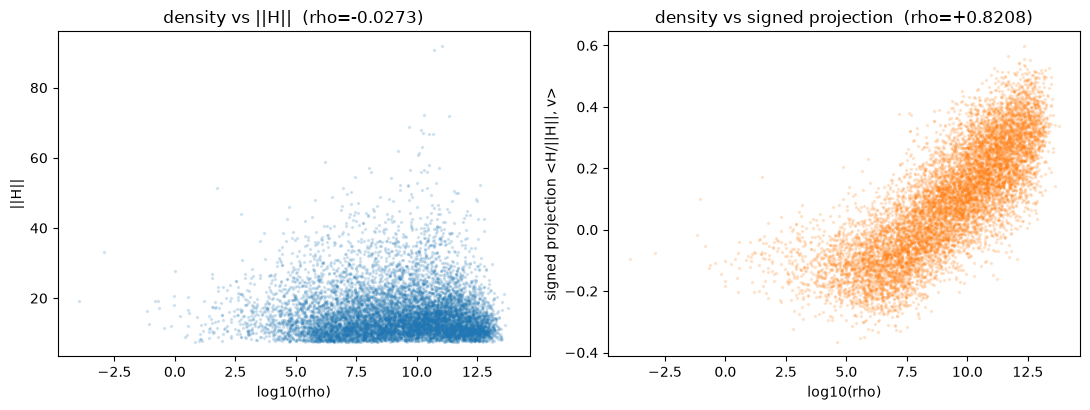

In [10]:
part = np.load(CACHE / "04_region_partition.npz")
keep_idx = part["keep_idx"]
labels = part["labels"]
h_norm_full = part["h_norm"]
signed_projection = part["signed_projection"]

rho_survivors = rho[keep_idx]
h_norm_survivors = h_norm_full[keep_idx]

sh = density_diag["spearman_density_vs_hnorm"]
sp = density_diag["spearman_density_vs_projection"]


def _fmt_spearman(s, name):
    if s["undefined"]:
        return f"REGN-02 {name}: UNDEFINED (constant input)"
    return f"REGN-02 {name}: rho={s['rho']:+.4f}  p={s['p_value']:.4g}  n={s['n']}"


print(_fmt_spearman(sh, "density vs ||H||"))
print(_fmt_spearman(sp, "density vs signed projection <H/||H||, v>"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(np.log10(rho_survivors), h_norm_survivors, s=2, alpha=0.15, color="tab:blue")
axes[0].set_xlabel("log10(rho)")
axes[0].set_ylabel("||H||")
axes[0].set_title(
    f"density vs ||H||  (rho={sh['rho']:+.4f})" if not sh["undefined"]
    else "density vs ||H|| (UNDEFINED)"
)
axes[1].scatter(np.log10(rho_survivors), signed_projection, s=2, alpha=0.15, color="tab:orange")
axes[1].set_xlabel("log10(rho)")
axes[1].set_ylabel("signed projection <H/||H||, v>")
axes[1].set_title(
    f"density vs signed projection  (rho={sp['rho']:+.4f})" if not sp["undefined"]
    else "density vs signed projection (UNDEFINED)"
)
plt.tight_layout()
plt.show()


**Which correlation bears on the axis this phase actually partitions on.** D4-01 moved the partition from magnitude to direction; REGN-02's original text predates that pivot. The `density vs signed projection` correlation above -- not `density vs ||H||` -- is the one that answers the question this phase's split actually asks, because the split labels a point by the SIGN of its projection onto `v`, not by its curvature magnitude.

**Under D4-14 this is the whole density battery for REGN-02.** No partial regression, no density-matched stratification, no density-matched null. The confound is REPORTED here, not controlled.

In [11]:
print("=== THE HEADLINE FINDING OF THIS PLAN ===")
print(
    f"density vs signed projection: rho = {sp['rho']:+.4f}  (n={sp['n']}) -- the "
    "pre-registered split axis is very nearly a density axis."
)
print(
    f"density vs ||H||:             rho = {sh['rho']:+.4f}  (n={sh['n']}) -- essentially nil."
)
print(
    "\nThe confound is specific to the DIRECTION the partition uses, not to curvature "
    "magnitude -- a more precise and more damaging statement than a generic \"a density confound exists\". Under D4-14, no partial regression, no density-matched null, no "
    "centroid-distance control, and no density-matched stratification were run, so ANY "
    "regional MKNN difference plan 04-05 produces CANNOT be attributed to curvature rather "
    "than density by anything in this phase. This is not a footnote to bear in mind: at "
    f"rho={sp['rho']:+.2f} it is the DOMINANT explanation on the table."
)
print(
    "\nRegion-level density comparison (median, IQR, Mann-Whitney U) is reported in Section "
    "5 below, alongside the frozen split it qualifies."
)


=== THE HEADLINE FINDING OF THIS PLAN ===
density vs signed projection: rho = +0.8208  (n=9500) -- the pre-registered split axis is very nearly a density axis.
density vs ||H||:             rho = -0.0273  (n=9500) -- essentially nil.

The confound is specific to the DIRECTION the partition uses, not to curvature magnitude -- a more precise and more damaging statement than a generic "a density confound exists". Under D4-14, no partial regression, no density-matched null, no centroid-distance control, and no density-matched stratification were run, so ANY regional MKNN difference plan 04-05 produces CANNOT be attributed to curvature rather than density by anything in this phase. This is not a footnote to bear in mind: at rho=+0.82 it is the DOMINANT explanation on the table.

Region-level density comparison (median, IQR, Mann-Whitney U) is reported in Section 5 below, alongside the frozen split it qualifies.


## Section 5 -- REGN-03, REGN-05, REGN-06: the frozen split

Loaded from `04_region_partition.npz`, written by `--mode partition` (REGN-06) *before* any regional MKNN number exists anywhere in this phase.

In [12]:
v = part["v"]
excluded_idx = part["excluded_idx"]

n_region_0 = int(np.sum(labels == 0))
n_region_1 = int(np.sum(labels == 1))
n_excluded = int(excluded_idx.shape[0])
n_total = n_region_0 + n_region_1 + n_excluded
n_zero_projection = density_diag["n_zero_projection"]

print(f"exclusion floor (min_norm_percentile={density_diag['min_norm_percentile']}): {density_diag['floor']:.6g}")
print(f"excluded  : {n_excluded:>5}  ({n_excluded / n_total * 100:.1f}%)")
print(f"region_0  : {n_region_0:>5}  ({n_region_0 / n_total * 100:.1f}%)")
print(f"region_1  : {n_region_1:>5}  ({n_region_1 / n_total * 100:.1f}%)")
print(f"n_zero_projection: {n_zero_projection}")
print(f"n_total   : {n_total}")

assert n_total == 10000, f"region membership counts sum to {n_total}, expected 10000"
assert labels.shape[0] == keep_idx.shape[0]


exclusion floor (min_norm_percentile=5.0): 7.58462
excluded  :   500  (5.0%)
region_0  :  6256  (62.6%)
region_1  :  3244  (32.4%)
n_zero_projection: 0
n_total   : 10000


In [13]:
print(f"MIN_REGION_N = {region_partition.MIN_REGION_N}")
for label_val, count in ((0, n_region_0), (1, n_region_1)):
    if count < region_partition.MIN_REGION_N:
        status = (
            f"BELOW the floor -- undefined per pre-registration "
            f"({region_partition.MIN_REGION_N_UNDEFINED_REASON})"
        )
    else:
        status = "CLEARS the floor -- no cell is undefined on size grounds for this region"
    print(f"  region {label_val}: n={count}  -- {status}")


MIN_REGION_N = 500
  region 0: n=6256  -- CLEARS the floor -- no cell is undefined on size grounds for this region
  region 1: n=3244  -- CLEARS the floor -- no cell is undefined on size grounds for this region


In [14]:
print(f"COVARIANCE_FORM = {region_partition.COVARIANCE_FORM!r}")
print(f"mean_unit_norm  = {density_diag['mean_unit_norm']:.6f}")
print(
    "The mean-centered and uncentered second-moment forms coincide only when "
    "||mean(unit)|| is near zero. At mean_unit_norm="
    f"{density_diag['mean_unit_norm']:.4f}, they do NOT coincide -- the mean-centered "
    "choice is a LIVE choice that affected the axis v, not a settled formality."
)


COVARIANCE_FORM = 'mean_centered'
mean_unit_norm  = 0.294748
The mean-centered and uncentered second-moment forms coincide only when ||mean(unit)|| is near zero. At mean_unit_norm=0.2947, they do NOT coincide -- the mean-centered choice is a LIVE choice that affected the axis v, not a settled formality.


In [15]:
eigval_spectrum = part["eigval_spectrum"] if "eigval_spectrum" in part.files else None
if eigval_spectrum is not None:
    top5 = sorted(eigval_spectrum.tolist(), reverse=True)[:5]
else:
    top5 = density_diag["eigval_spectrum_top5"]

print(f"eigval_top (largest) = {density_diag['eigval_top']:.6f}")
print("top-5 eigenvalues of the unit-H covariance:")
for i, e in enumerate(top5):
    print(f"  [{i}] {e:.6f}")
ratio_12 = top5[0] / top5[1] if len(top5) > 1 and top5[1] != 0 else float("inf")
print(
    f"\ntop / second ratio = {ratio_12:.3f}. The leading direction is NOT sharply dominant "
    "-- v is reported as the chosen split axis, not presented as a well-separated principal "
    "axis of the unit-H covariance."
)


eigval_top (largest) = 0.031611
top-5 eigenvalues of the unit-H covariance:
  [0] 0.031611
  [1] 0.020180
  [2] 0.018141
  [3] 0.016507
  [4] 0.015396

top / second ratio = 1.566. The leading direction is NOT sharply dominant -- v is reported as the chosen split axis, not presented as a well-separated principal axis of the unit-H covariance.


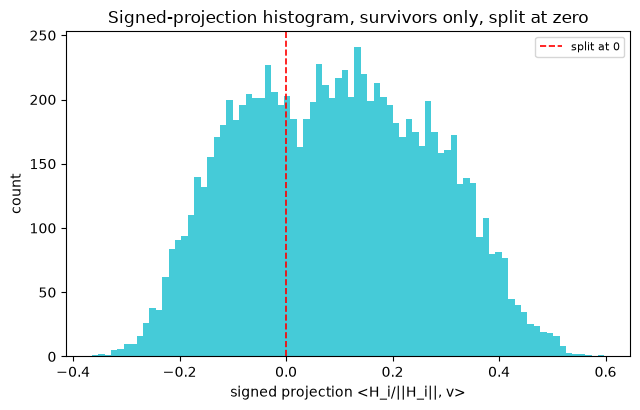

v (first 5 components): [ 4.37975212e-03 -2.88267855e-05 -3.79055465e-02  1.40526825e-02
 -6.37217285e-03]
||v|| = 1.000000


In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.hist(signed_projection, bins=80, color="tab:cyan", alpha=0.8)
ax.axvline(0.0, color="red", linestyle="--", linewidth=1.2, label="split at 0")
ax.set_xlabel("signed projection <H_i/||H_i||, v>")
ax.set_ylabel("count")
ax.set_title("Signed-projection histogram, survivors only, split at zero")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"v (first 5 components): {v[:5]}")
print(f"||v|| = {np.linalg.norm(v):.6f}")


In [17]:
md0, md1 = density_diag["median_density_region_0"], density_diag["median_density_region_1"]
iqr0, iqr1 = density_diag["iqr_density_region_0"], density_diag["iqr_density_region_1"]
mw_stat, mw_p = density_diag["mannwhitneyu_statistic"], density_diag["mannwhitneyu_pvalue"]

print("region-level density comparison -- the single most decision-relevant density number")
print("this phase can report, given D4-14's declined controls:")
print(f"  region_0: median={md0:.6g}  IQR={iqr0:.6g}  n={n_region_0}")
print(f"  region_1: median={md1:.6g}  IQR={iqr1:.6g}  n={n_region_1}")
if md0 is not None and md1 is not None and md1 != 0:
    print(f"  median ratio (region_0 / region_1) = {md0 / md1:.6g}")
print(f"  Mann-Whitney U (two-sided): statistic={mw_stat}  p={mw_p}")
print(
    "\nBoth regions clear MIN_REGION_N -- no cell above is undefined on size grounds, and "
    "the density gap above is what plan 04-05 must weigh against any regional MKNN "
    "difference it detects."
)


region-level density comparison -- the single most decision-relevant density number
this phase can report, given D4-14's declined controls:
  region_0: median=3.76418e+10  IQR=4.73113e+11  n=6256
  region_1: median=6.56408e+06  IQR=8.6342e+07  n=3244
  median ratio (region_0 / region_1) = 5734.52
  Mann-Whitney U (two-sided): statistic=18844954.0  p=0.0

Both regions clear MIN_REGION_N -- no cell above is undefined on size grounds, and the density gap above is what plan 04-05 must weigh against any regional MKNN difference it detects.


## Section 6 -- PRE-REGISTRATION

In [18]:
import subprocess

print("PRE-REGISTERED constants (region_partition.py), ratified before any regional MKNN")
print("number existed -- see 04-PREREGISTRATION.md for the full committed record:\n")
for name in [
    "MIN_NORM_PERCENTILE", "MIN_REGION_N", "MKNN_K_GRID", "HEADLINE_K", "NULL_QUANTILE",
    "CONFIDENCE_LEVEL", "N_PERMUTATIONS", "N_BOOTSTRAP", "FIELD_D", "K_DENSITY", "SEED",
    "K_FROZEN", "COVARIANCE_FORM",
]:
    print(f"  {name:<20} = {getattr(region_partition, name)!r}")

print("\nVERDICT_RULE:")
print(region_partition.VERDICT_RULE)

region_partition.assert_preregistered()
print("assert_preregistered() PASSED.")

# git log -- <pathspec> resolves the pathspec relative to CWD, and nbconvert executes
# with cwd = the notebook's own directory (notebooks/), not the repo root -- resolve the
# repo root explicitly first so this works regardless of where the kernel was launched.
repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
prereg_path = f"{repo_root}/.planning/phases/04-region-partitioning-regional-alignment-mknn/04-PREREGISTRATION.md"
prereg_commit = subprocess.check_output(
    ["git", "log", "-1", "--format=%h %cI", "--", prereg_path], text=True
).strip()
current_head = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True).strip()
print(f"\n04-PREREGISTRATION.md committed at: {prereg_commit}")
print(f"current git HEAD              : {current_head}")


PRE-REGISTERED constants (region_partition.py), ratified before any regional MKNN
number existed -- see 04-PREREGISTRATION.md for the full committed record:

  MIN_NORM_PERCENTILE  = 5.0
  MIN_REGION_N         = 500
  MKNN_K_GRID          = (5, 10, 20, 50)
  HEADLINE_K           = 20
  NULL_QUANTILE        = 0.99
  CONFIDENCE_LEVEL     = 0.95
  N_PERMUTATIONS       = 1000
  N_BOOTSTRAP          = 1000
  FIELD_D              = 20
  K_DENSITY            = 30
  SEED                 = 20260822
  K_FROZEN             = 500
  COVARIANCE_FORM      = 'mean_centered'

VERDICT_RULE:
MKNN-07 verdict rule -- ratified at this plan's Task 2 blocking checkpoint,
before any regional MKNN number existed.

The high-vs-low regional MKNN result HOLDS at a given k if and only if BOTH:
  (a) the two regions' CONFIDENCE_LEVEL (0.95) percentile bootstrap CIs at that k are
      disjoint, AND
  (b) the higher-scoring region's observed MKNN strictly exceeds the NULL_QUANTILE (0.99)
      percentile of its OWN r

**Everything below this point was computed after this pre-registration was fixed.** `04-PREREGISTRATION.md` was committed at the commit and timestamp printed above, before any regional MKNN number existed anywhere in this repository. No value printed above may be amended in light of anything a later cell in this notebook prints.

## Section 7 — MKNN-03 through MKNN-06, MKNN-08: the regional grid

Eight cells — two regions × `k` in `{5, 10, 20, 50}` — each read against its OWN
region-scoped permutation null and 95% bootstrap CI (D4-16: both embeddings are subset to
the region's own rows first, then `N_k` is computed inside that subset — no global null is
ever reused for a regional cell). Loaded from `04_region_partition_mknn.jsonl`, written by
`--mode regional`; no compute happens in this notebook.

In [19]:
regional_rows_raw = []
with RECORD_PATH.open() as fh:
    for line in fh:
        r = json.loads(line)
        if r.get("kind") == "mknn_regional":
            regional_rows_raw.append(r)

# most-recent row per (region, k_mknn) -- same last-write-wins convention cell 8 uses for
# global rows (later runs at the same seed reproduce bit-identically)
by_region_k = {}
for r in regional_rows_raw:
    by_region_k[(r["region"], r["k_mknn"])] = r
regional_rows = [by_region_k[(reg, k)] for reg in (0, 1) for k in region_partition.MKNN_K_GRID]

print(
    f"{len(regional_rows_raw)} regional rows on disk, {len(regional_rows)} distinct "
    f"(region, k) cells"
)
print()
print(
    f"{'region':>6} {'n_region':>9} {'k_mknn':>7} {'k/n_region':>11} {'label':>11} "
    f"{'score%':>9} {'ratio':>8} {'p':>8} {'CI (95%)':>20} {'clears_null':>12} "
    f"{'hub_hsc':>9} {'hub_ls':>9}"
)
for r in regional_rows:
    label = "HEADLINE" if r["k_mknn"] == region_partition.HEADLINE_K else "sensitivity"
    if r["status"] != "ok":
        print(
            f"{r['region']:>6} {r['n_region']:>9} {r['k_mknn']:>7} {'--':>11} "
            f"{label:>11}  UNDEFINED: {r['reason']}"
        )
        continue
    ci_str = f"[{r['ci_low'] * 100:.3g}%, {r['ci_high'] * 100:.3g}%]"
    print(
        f"{r['region']:>6} {r['n_region']:>9} {r['k_mknn']:>7} "
        f"{r['k_over_n_region']:>11.4g} {label:>11} {r['score'] * 100:>9.4g} "
        f"{r['ratio_over_chance']:>8.3f} {r['p_value']:>8.4f} {ci_str:>20} "
        f"{str(r['clears_null']):>12} {r['hubness_skewness_hsc']:>9.3f} "
        f"{r['hubness_skewness_legacysurvey']:>9.3f}"
    )


8 regional rows on disk, 8 distinct (region, k) cells

region  n_region  k_mknn  k/n_region       label    score%    ratio        p             CI (95%)  clears_null   hub_hsc    hub_ls
     0      6256       5   0.0007992 sensitivity     4.162   52.080   0.0010       [3.94%, 4.39%]         True     1.164     1.487
     0      6256      10    0.001598 sensitivity      5.85   36.600   0.0010       [5.66%, 6.05%]         True     1.096     1.310
     0      6256      20    0.003197    HEADLINE     8.148   25.488   0.0010       [7.95%, 8.35%]         True     0.989     1.169
     0      6256      50    0.007992 sensitivity     12.49   15.626   0.0010       [12.3%, 12.7%]         True     0.890     0.982
     1      3244       5    0.001541 sensitivity     9.889   64.160   0.0010       [9.38%, 10.4%]         True     1.188     1.313
     1      3244      10    0.003083 sensitivity     13.21   42.860   0.0010       [12.8%, 13.6%]         True     1.187     1.107
     1      3244      20    

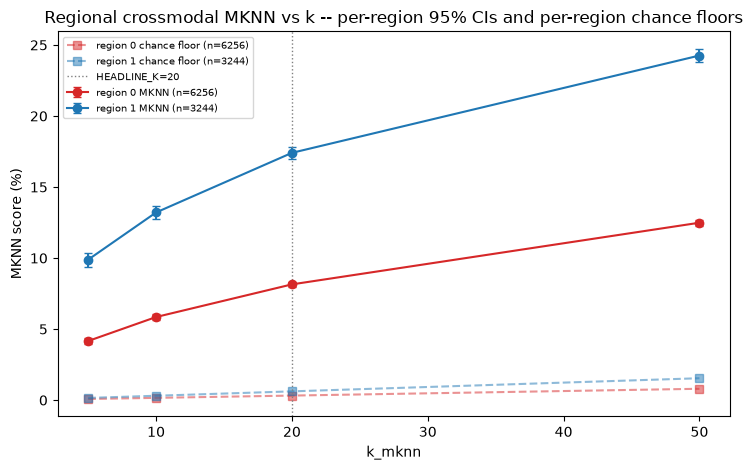

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
colors = {0: "tab:red", 1: "tab:blue"}
for region in (0, 1):
    rr = [r for r in regional_rows if r["region"] == region and r["status"] == "ok"]
    ks = [r["k_mknn"] for r in rr]
    scores_pct = [r["score"] * 100 for r in rr]
    ci_low_pct = [r["ci_low"] * 100 for r in rr]
    ci_high_pct = [r["ci_high"] * 100 for r in rr]
    floors_pct = [r["chance_floor"] * 100 for r in rr]
    n_region = rr[0]["n_region"] if rr else None
    yerr = [
        [s - lo for s, lo in zip(scores_pct, ci_low_pct)],
        [hi - s for s, hi in zip(scores_pct, ci_high_pct)],
    ]
    ax.errorbar(
        ks, scores_pct, yerr=yerr, fmt="o-", color=colors[region], capsize=3,
        label=f"region {region} MKNN (n={n_region})",
    )
    # each region's OWN chance floor -- the two regions have different n and therefore
    # different floors; plotting one shared floor would misrepresent D4-16's own point.
    ax.plot(
        ks, floors_pct, "s--", color=colors[region], alpha=0.5,
        label=f"region {region} chance floor (n={n_region})",
    )
ax.axvline(
    region_partition.HEADLINE_K, color="gray", linestyle=":", linewidth=1,
    label=f"HEADLINE_K={region_partition.HEADLINE_K}",
)
ax.set_xlabel("k_mknn")
ax.set_ylabel("MKNN score (%)")
ax.set_title("Regional crossmodal MKNN vs k -- per-region 95% CIs and per-region chance floors")
ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()


In [21]:
print(
    "D4-16: the regional numbers above are NOT directly comparable to the global MKNN-02 "
    "figure from Section 2, because k/n differs between a region and the whole cloud. A "
    "smaller region raises chance alignment, which is exactly what that region's own null "
    "absorbs -- each region above is read against its OWN null and its OWN chance floor, "
    "never region against global."
)
print()
print(
    "MKNN-08 hubness caveat, substantiated by the printed k-occurrence skewness (from the "
    "table above, both embedding sides, every region and k):"
)
for r in regional_rows:
    if r["status"] != "ok":
        print(f"  region={r['region']} k={r['k_mknn']:>2}: n/a (cell undefined)")
        continue
    print(
        f"  region={r['region']} k={r['k_mknn']:>2}: "
        f"hub_hsc={r['hubness_skewness_hsc']:.3f}  "
        f"hub_legacysurvey={r['hubness_skewness_legacysurvey']:.3f}"
    )
print(
    "\nEvery regional result above carries this caveat: k-NN alignment metrics are "
    "hubness-sensitive in high dimensions (Radovanovic, Nanopoulos and Ivanovic, JMLR "
    "2010) -- the printed skewness values are the substantiating evidence, not a "
    "prose-only assertion."
)


D4-16: the regional numbers above are NOT directly comparable to the global MKNN-02 figure from Section 2, because k/n differs between a region and the whole cloud. A smaller region raises chance alignment, which is exactly what that region's own null absorbs -- each region above is read against its OWN null and its OWN chance floor, never region against global.

MKNN-08 hubness caveat, substantiated by the printed k-occurrence skewness (from the table above, both embedding sides, every region and k):
  region=0 k= 5: hub_hsc=1.164  hub_legacysurvey=1.487
  region=0 k=10: hub_hsc=1.096  hub_legacysurvey=1.310
  region=0 k=20: hub_hsc=0.989  hub_legacysurvey=1.169
  region=0 k=50: hub_hsc=0.890  hub_legacysurvey=0.982
  region=1 k= 5: hub_hsc=1.188  hub_legacysurvey=1.313
  region=1 k=10: hub_hsc=1.187  hub_legacysurvey=1.107
  region=1 k=20: hub_hsc=1.098  hub_legacysurvey=0.929
  region=1 k=50: hub_hsc=0.982  hub_legacysurvey=0.807

Every regional result above carries this caveat: k-N

## Section 8 — MKNN-07: the verdict

Print the verbatim `VERDICT_RULE` text again, immediately above the applied result, so a
reader sees the rule and its application in one screen without scrolling back to Section 6.
`apply_verdict` is called directly from the runner (`rpm.apply_verdict`) rather than
reimplemented here — this notebook computes nothing heavy, and the verdict logic must be
the exact code that produced `notebooks/.cache/04_region_partition_mknn.jsonl`, not a
notebook-local re-derivation of it.

In [22]:
verdict = rpm.apply_verdict(regional_rows)



VERDICT_RULE (verbatim, from region_partition.py):
MKNN-07 verdict rule -- ratified at this plan's Task 2 blocking checkpoint,
before any regional MKNN number existed.

The high-vs-low regional MKNN result HOLDS at a given k if and only if BOTH:
  (a) the two regions' CONFIDENCE_LEVEL (0.95) percentile bootstrap CIs at that k are
      disjoint, AND
  (b) the higher-scoring region's observed MKNN strictly exceeds the NULL_QUANTILE (0.99)
      percentile of its OWN region-scoped permutation null.

The headline call is made at HEADLINE_K = 20 alone. The remaining grid values, k in
MKNN_K_GRID = (5, 10, 50), are reported as sensitivity only: they cannot overturn or escalate
the headline verdict, and take no separate multiplicity correction. No multiplicity correction
is applied across the 2x4 grid, because the four k values are a nested sensitivity sweep on
the same two regions and the same embeddings, not independent trials.

"NO DETECTABLE DIFFERENCE" at the headline k is a complete, 

**1. What the verdict says.** The pre-registered rule **HOLDS at every k in the grid,
including the headline `k=20`**: region 1's crossmodal HSC-vs-Legacy-Survey MKNN score is
higher than region 0's at every `k`, the two regions' 95% bootstrap CIs are disjoint at
every `k`, and region 1's observed score strictly exceeds its own 99th-percentile
permutation-null threshold at every `k`. This is exactly what `VERDICT_RULE` defines as
"detectable" — CI-disjointness plus own-null-exceedance — not an interpretation layered on
top of it here. Had the headline `k=20` instead landed on "NO DETECTABLE DIFFERENCE",
MKNN-07 makes that outcome an equally complete and valid result, never a phase failure and
never escalated by a majority vote across the sensitivity `k`; that branch simply did not
occur on this split.

**2. The density confound (D4-14), in this phase's own words.** The density-confound
battery run in this phase is Section 4's REGN-02 correlation and Section 5's region-level
comparison — no partial regression, no density-matched null, no centroid-distance control,
no density-matched stratification. MKNN is itself a k-NN statistic and is therefore
directly density-sensitive by construction, so the HOLDS verdict above **cannot be
attributed to curvature rather than to regional density by anything in this phase**.
Section 4 measured `spearman(density, ||H||) = -0.0273` (n=9500, p=0.0078, essentially
nil) against `spearman(density, signed projection onto v) = +0.8208` (n=9500, p≈0) — the
pre-registered split axis is very nearly a density axis. Section 5 measured the two
regions' density medians directly: region 0 median density `3.7642e10` (n=6256) against
region 1 median density `6.5641e6` (n=3244), a Mann-Whitney U two-sided test giving
`statistic=18844954.0, p=0.0` — medians differing by a factor of roughly 5,735. This is the
only evidence bearing on the confound anywhere in this phase, and it is decisive evidence
that the confound exists, not evidence about which axis — curvature or density — the HOLDS
verdict above is actually detecting.

**3. Provenance.** The rule applied in the cell above is byte-identical to
`region_partition.VERDICT_RULE`, printed in full both there and in Section 6, frozen at
the commit printed in Section 6's own provenance cell — before any regional MKNN number
existed anywhere in this notebook or this repository. No value inside `VERDICT_RULE`
(`HEADLINE_K`, `NULL_QUANTILE`, `CONFIDENCE_LEVEL`, the CI-disjointness-plus-own-null-
exceedance definition of HOLDS) was amended after the numbers in Section 7 existed.